In [ ]:
import sys
!{sys.executable} -m pip install cellpose

In [ ]:
import cellpose
print("Cellpose imported successfully")
print("Location:", cellpose.__file__)

Cellpose imported successfully
Location: /usr/local/lib/python3.13/dist-packages/cellpose/__init__.py


Image shape: (209, 250, 3)


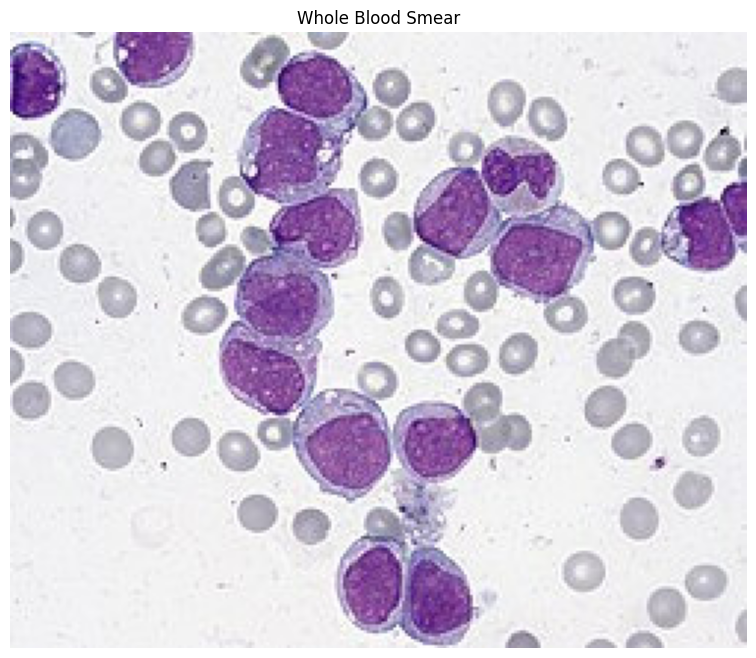

In [347]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from cellpose import models

# Load whole-smear image
image_path = "/my04.jpeg"

image = np.array(Image.open(image_path).convert("RGB"))

print("Image shape:", image.shape)

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Whole Blood Smear")
plt.show()

In [348]:
model_cp = models.CellposeModel(
    gpu=True
)

print("Cellpose model loaded successfully.")

Cellpose model loaded successfully.


In [349]:
masks, flows, styles = model_cp.eval(
    image,
    channels=[0, 0],
    diameter=0
)

print("Number of detected objects:", masks.max())
print("Mask shape:", masks.shape)

Number of detected objects: 83
Mask shape: (209, 250)


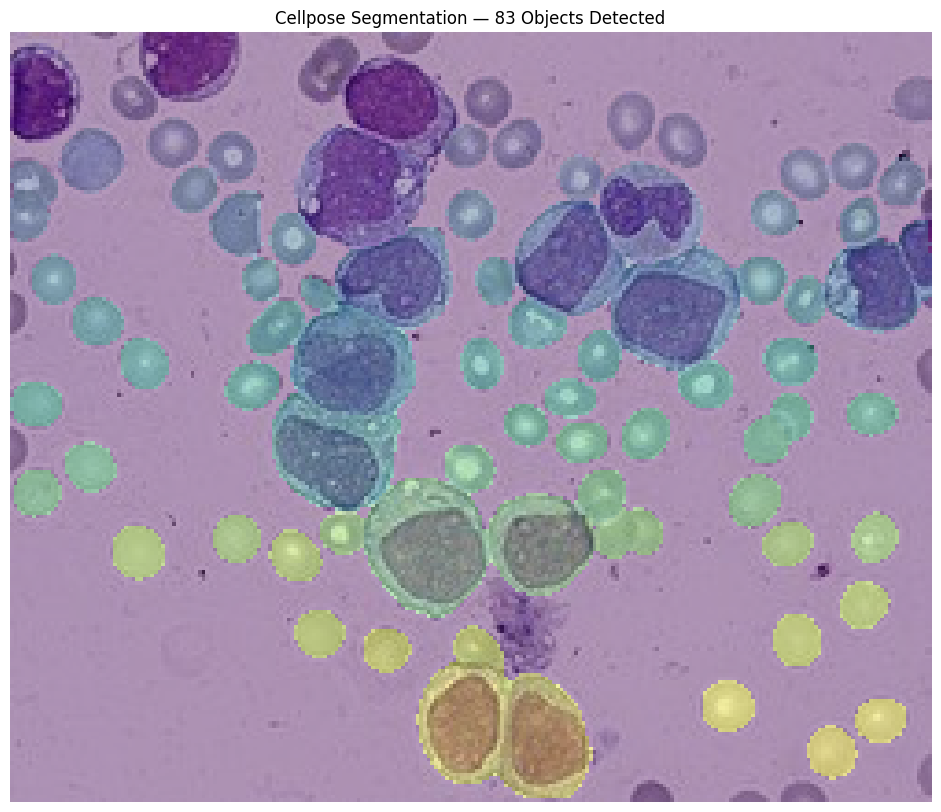

In [350]:
plt.figure(figsize=(14, 10))

plt.imshow(image)
plt.imshow(masks, alpha=0.4)

plt.axis("off")
plt.title(f"Cellpose Segmentation — {masks.max()} Objects Detected")
plt.show()

In [351]:
import pandas as pd
import numpy as np

objects = []

for label in range(1, int(masks.max()) + 1):
    ys, xs = np.where(masks == label)

    if len(xs) == 0:
        continue

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    objects.append({
        "label": label,
        "area": len(xs),
        "width": x2 - x1 + 1,
        "height": y2 - y1 + 1,
        "center_x": xs.mean(),
        "center_y": ys.mean()
    })

objects_df = pd.DataFrame(objects)

print(objects_df.sort_values("area", ascending=False).to_string(index=False))

 label  area  width  height   center_x   center_y
    64   988     34      38 112.536437 138.828947
    12   897     37      34  94.294314  41.969900
    33   894     35      34 180.217002  74.718121
    52   821     35      32  87.348356 113.937881
    43   796     34      30  92.684673  89.356784
    28   697     32      31 151.074605  61.340029
    80   684     26      34 143.915205 191.736842
    79   661     25      34 122.611195 186.403933
    31   647     32      28 104.972179  66.394127
    65   630     30      28 143.214286 138.207937
    21   608     29      28 173.065789  48.766447
     4   597     31      29 105.418760  19.753769
    32   501     27      26 233.001996  69.069860
     1   445     28      19  48.033708   8.056180
     3   400     19      26   8.612500  16.302500
    14   239     18      18  21.694561  34.468619
     2   214     17      18  86.116822   9.635514
    24   204     15      18  61.490196  51.710784
    42   172     16      15  71.790698  79.895349


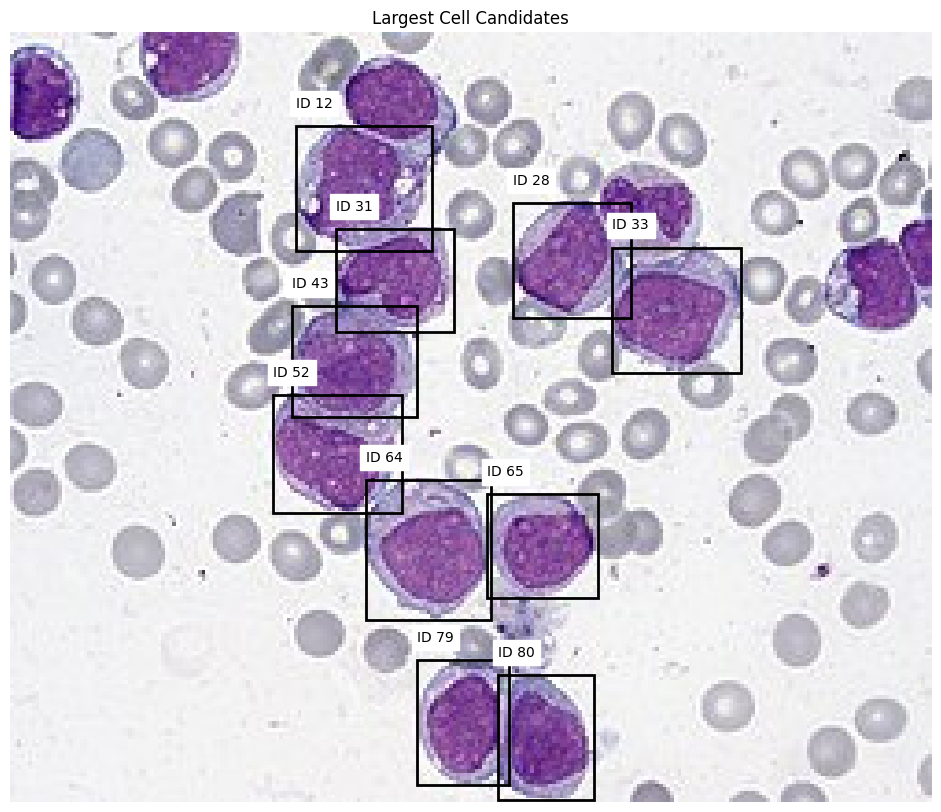

In [352]:
top_labels = objects_df.nlargest(10, "area")["label"].tolist()

plt.figure(figsize=(14, 10))
plt.imshow(image)

for label in top_labels:
    ys, xs = np.where(masks == label)

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1 + 1,
            y2 - y1 + 1,
            fill=False,
            linewidth=2
        )
    )

    plt.text(
        x1,
        y1 - 5,
        f"ID {label}",
        fontsize=10,
        backgroundcolor="white"
    )

plt.axis("off")
plt.title("Largest Cell Candidates")
plt.show()

In [353]:
print(
    objects_df
    .sort_values("area", ascending=False)
    .to_string(index=False)
)

 label  area  width  height   center_x   center_y
    64   988     34      38 112.536437 138.828947
    12   897     37      34  94.294314  41.969900
    33   894     35      34 180.217002  74.718121
    52   821     35      32  87.348356 113.937881
    43   796     34      30  92.684673  89.356784
    28   697     32      31 151.074605  61.340029
    80   684     26      34 143.915205 191.736842
    79   661     25      34 122.611195 186.403933
    31   647     32      28 104.972179  66.394127
    65   630     30      28 143.214286 138.207937
    21   608     29      28 173.065789  48.766447
     4   597     31      29 105.418760  19.753769
    32   501     27      26 233.001996  69.069860
     1   445     28      19  48.033708   8.056180
     3   400     19      26   8.612500  16.302500
    14   239     18      18  21.694561  34.468619
     2   214     17      18  86.116822   9.635514
    24   204     15      18  61.490196  51.710784
    42   172     16      15  71.790698  79.895349


In [354]:
print("Total Cellpose objects:", len(objects_df))
print("Largest area:", objects_df["area"].max())
print("Smallest area:", objects_df["area"].min())

Total Cellpose objects: 83
Largest area: 988
Smallest area: 73


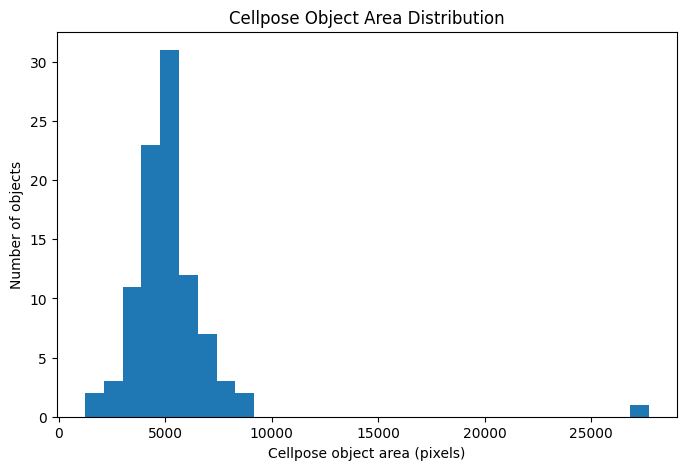

In [305]:
import numpy as np
import matplotlib.pyplot as plt

areas = objects_df["area"].values

plt.figure(figsize=(8, 5))
plt.hist(areas, bins=30)
plt.xlabel("Cellpose object area (pixels)")
plt.ylabel("Number of objects")
plt.title("Cellpose Object Area Distribution")
plt.show()

In [355]:
# Use the 80th percentile as an initial adaptive threshold
if len(objects_df)>10:
  adaptive_threshold = np.percentile(objects_df["area"],82)
else:
  adaptive_threshold = np.percentile(
        objects_df["area"],
        0
    )

print("Adaptive area threshold:", adaptive_threshold)

wbc_df = objects_df[
    objects_df["area"] >= adaptive_threshold
].copy()

wbc_df = wbc_df.sort_values(
    "area",
    ascending=False
).reset_index(drop=True)

print("WBC candidates:", len(wbc_df))
print(wbc_df.to_string(index=False))

Adaptive area threshold: 277.6399999999992
WBC candidates: 15
 label  area  width  height   center_x   center_y
    64   988     34      38 112.536437 138.828947
    12   897     37      34  94.294314  41.969900
    33   894     35      34 180.217002  74.718121
    52   821     35      32  87.348356 113.937881
    43   796     34      30  92.684673  89.356784
    28   697     32      31 151.074605  61.340029
    80   684     26      34 143.915205 191.736842
    79   661     25      34 122.611195 186.403933
    31   647     32      28 104.972179  66.394127
    65   630     30      28 143.214286 138.207937
    21   608     29      28 173.065789  48.766447
     4   597     31      29 105.418760  19.753769
    32   501     27      26 233.001996  69.069860
     1   445     28      19  48.033708   8.056180
     3   400     19      26   8.612500  16.302500


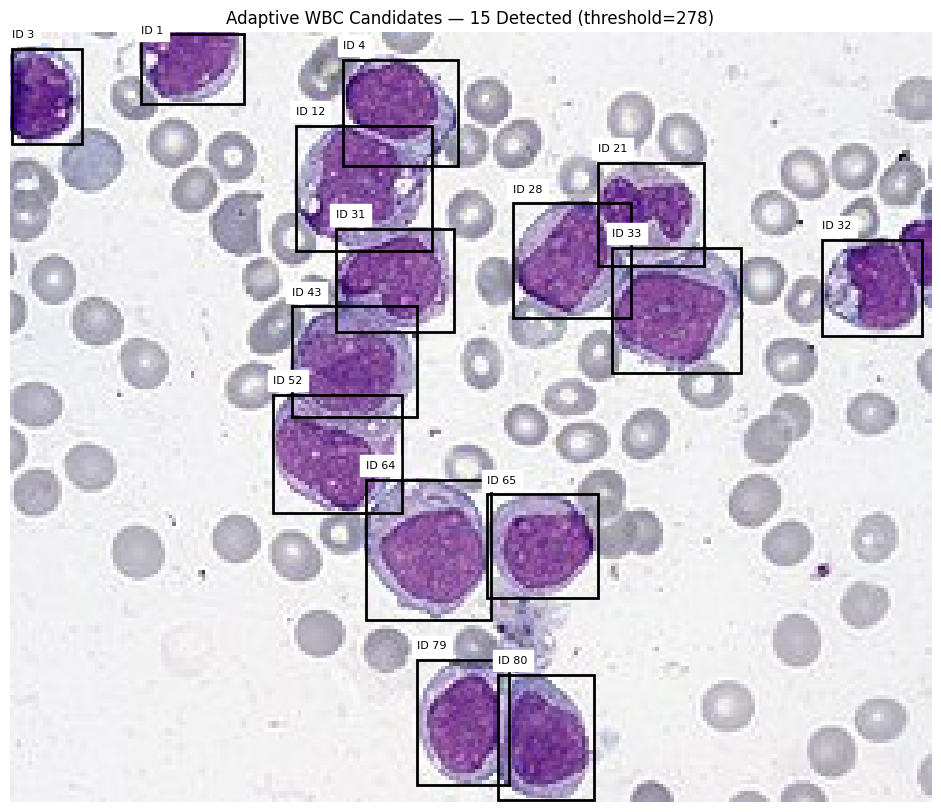

In [356]:
plt.figure(figsize=(14, 10))
plt.imshow(image)

for _, row in wbc_df.iterrows():

    label = int(row["label"])
    ys, xs = np.where(masks == label)

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1 + 1,
            y2 - y1 + 1,
            fill=False,
            linewidth=2
        )
    )

    plt.text(
        x1,
        max(0, y1 - 3),
        f"ID {label}",
        fontsize=8,
        backgroundcolor="white"
    )

plt.axis("off")
plt.title(
    f"Adaptive WBC Candidates — "
    f"{len(wbc_df)} Detected "
    f"(threshold={adaptive_threshold:.0f})"
)
plt.show()

In [357]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

wbc_crops = []

for _, row in wbc_df.iterrows():

    label = int(row["label"])

    ys, xs = np.where(masks == label)

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    # Add padding around the Cellpose bounding box
    padding = 20

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(image.shape[1], x2 + padding)
    y2 = min(image.shape[0], y2 + padding)

    crop = image[y1:y2, x1:x2]

    wbc_crops.append({
        "label": label,
        "crop": crop,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2
    })

print("Extracted WBC crops:", len(wbc_crops))

Extracted WBC crops: 15


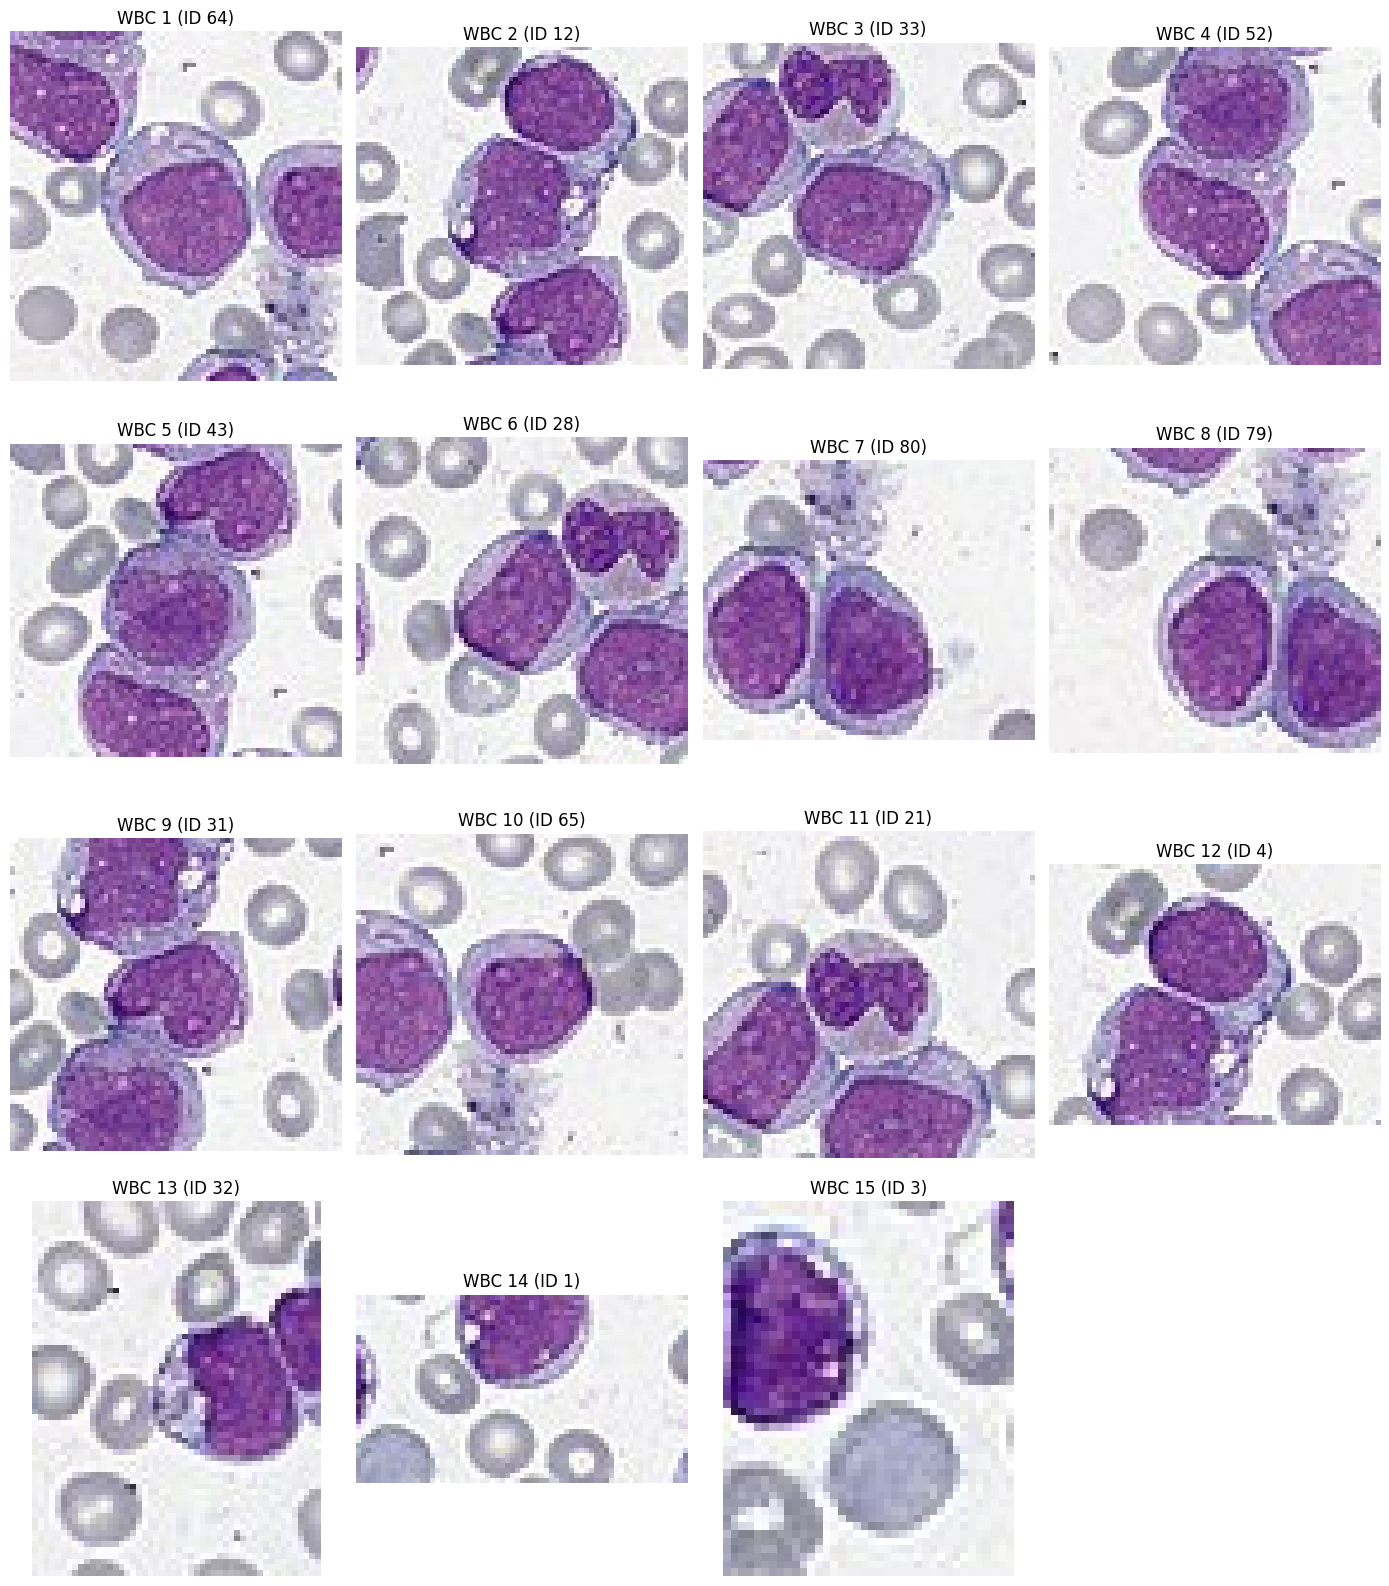

In [358]:
import math

n = len(wbc_crops)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, 4 * rows)
)

axes = np.array(axes).flatten()

for i, item in enumerate(wbc_crops):

    axes[i].imshow(item["crop"])
    axes[i].set_title(
        f"WBC {i+1} (ID {item['label']})"
    )
    axes[i].axis("off")

# Hide unused panels
for i in range(n, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [359]:
clean_wbc_crops = []

h, w = masks.shape

for _, row in wbc_df.iterrows():

    label = int(row["label"])

    ys, xs = np.where(masks == label)

    # Skip cells touching image boundary
    if (
        xs.min() <= 1 or
        ys.min() <= 1 or
        xs.max() >= w - 2 or
        ys.max() >= h - 2
    ):
        print(f"Skipping boundary object: ID {label}")
        continue

    # Bounding box
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    padding = 20

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding + 1)
    y2 = min(h, y2 + padding + 1)

    crop = image[y1:y2, x1:x2].copy()

    # Keep ONLY this Cellpose object
    mask_crop = (masks[y1:y2, x1:x2] == label)

    clean_crop = crop.copy()
    clean_crop[~mask_crop] = 255

    clean_wbc_crops.append({
        "label": label,
        "crop": clean_crop,
        "mask": mask_crop,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2
    })

print("Clean WBC crops:", len(clean_wbc_crops))

Skipping boundary object: ID 80
Skipping boundary object: ID 1
Skipping boundary object: ID 3
Clean WBC crops: 12


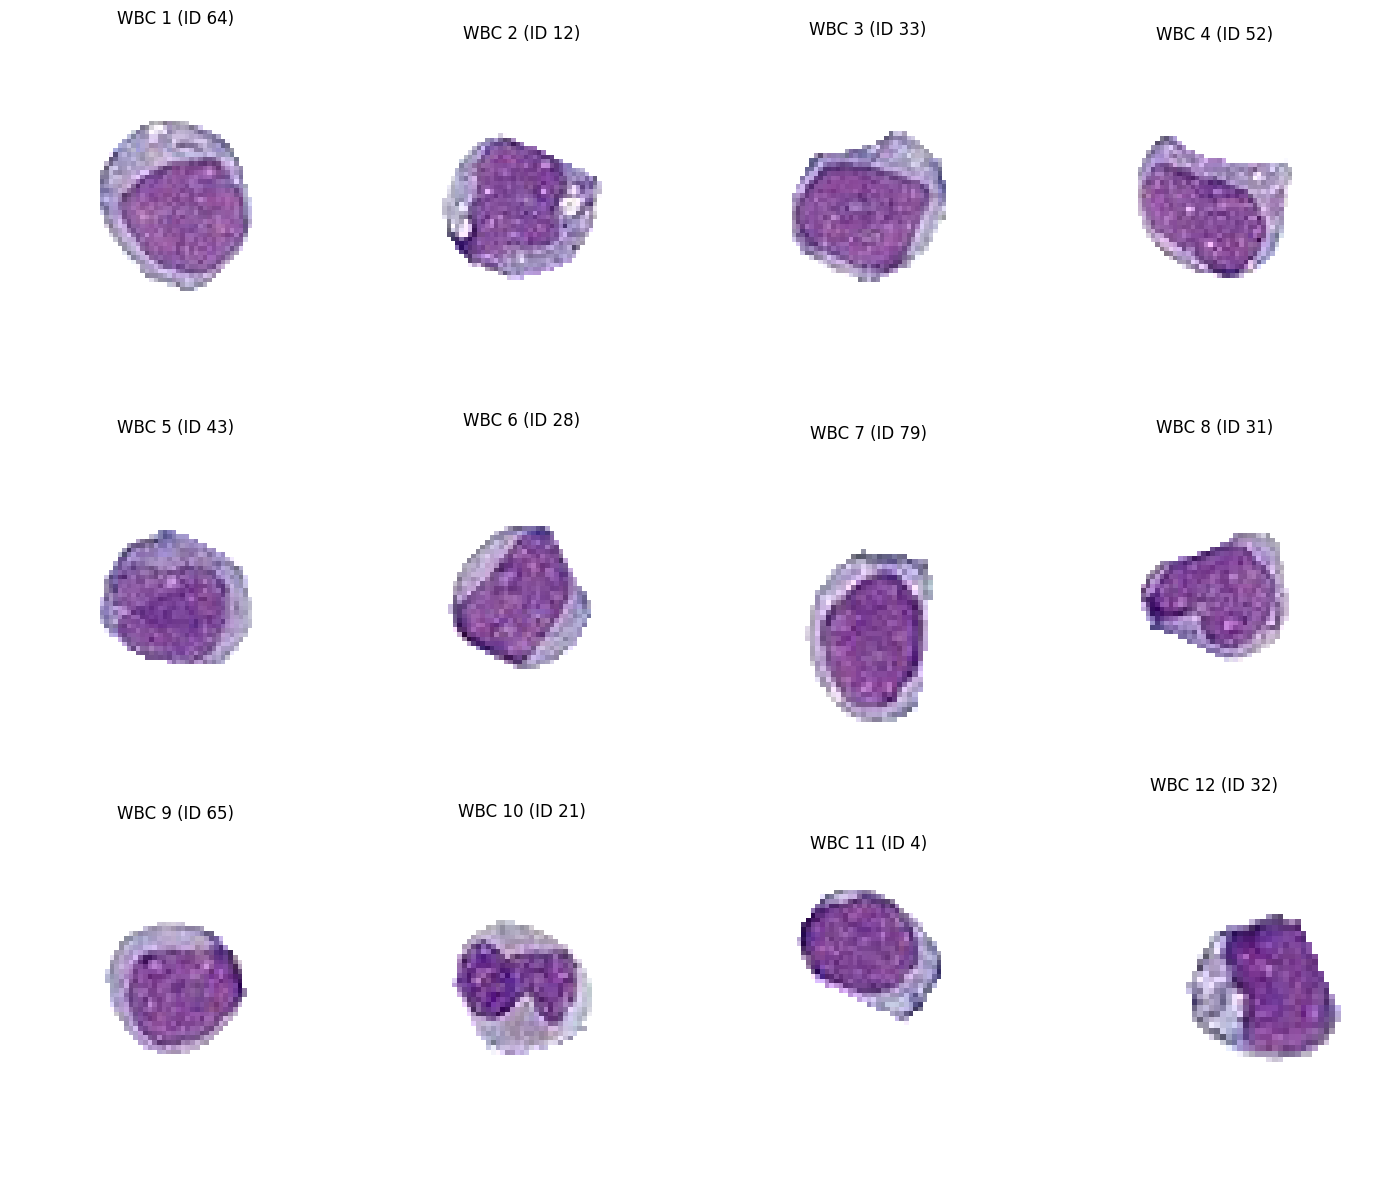

In [360]:
import math

n = len(clean_wbc_crops)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, 4 * rows)
)

axes = np.array(axes).flatten()

for i, item in enumerate(clean_wbc_crops):

    axes[i].imshow(item["crop"])
    axes[i].set_title(
        f"WBC {i+1} (ID {item['label']})"
    )
    axes[i].axis("off")

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [361]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import load_model

IMG_SIZE = (384, 384)

resnet_inputs = []

for item in clean_wbc_crops:

    crop = item["crop"]

    # Find non-white pixels to get a tighter bounding region
    gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
    coords = np.column_stack(np.where(gray < 245))

    if len(coords) > 0:
        y1, x1 = coords.min(axis=0)
        y2, x2 = coords.max(axis=0)

        crop = crop[y1:y2+1, x1:x2+1]

    # Make square canvas
    h, w = crop.shape[:2]
    size = max(h, w)

    square = np.ones((size, size, 3), dtype=np.uint8) * 255

    y_offset = (size - h) // 2
    x_offset = (size - w) // 2

    square[
        y_offset:y_offset+h,
        x_offset:x_offset+w
    ] = crop

    # Resize exactly like the ResNet input
    resized = cv2.resize(square, IMG_SIZE)

    resnet_inputs.append(resized)

resnet_inputs = np.array(resnet_inputs)

print("ResNet input shape:", resnet_inputs.shape)
MODEL_PATH = "/resnet50_frozen_384.keras"

model = load_model(MODEL_PATH)

ResNet input shape: (12, 384, 384, 3)


In [362]:
X_wbc = preprocess_input(
    resnet_inputs.astype(np.float32)
)

pred_probs = model.predict(
    X_wbc,
    verbose=1
)

pred_indices = np.argmax(pred_probs, axis=1)
pred_confidence = np.max(pred_probs, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


In [363]:
class_names = [
    "basophil",
    "erythroblast",
    "monocyte",
    "myeloblast",
    "seg_neutrophil"
]

results = []

for i in range(len(resnet_inputs)):
    results.append({
        "WBC": i + 1,
        "Cellpose_ID": clean_wbc_crops[i]["label"],
        "Prediction": class_names[pred_indices[i]],
        "Confidence": pred_confidence[i] * 100
    })

results_df = pd.DataFrame(results)

results_df["Confidence"] = results_df["Confidence"].round(2)

print(results_df.to_string(index=False))

 WBC  Cellpose_ID Prediction  Confidence
   1           64 myeloblast   98.760002
   2           12 myeloblast   73.790001
   3           33 myeloblast   99.870003
   4           52 myeloblast   96.099998
   5           43 myeloblast   70.870003
   6           28 myeloblast   95.519997
   7           79 myeloblast   95.680000
   8           31 myeloblast   86.279999
   9           65 myeloblast   95.680000
  10           21   monocyte   72.559998
  11            4 myeloblast   92.750000
  12           32 myeloblast   78.629997


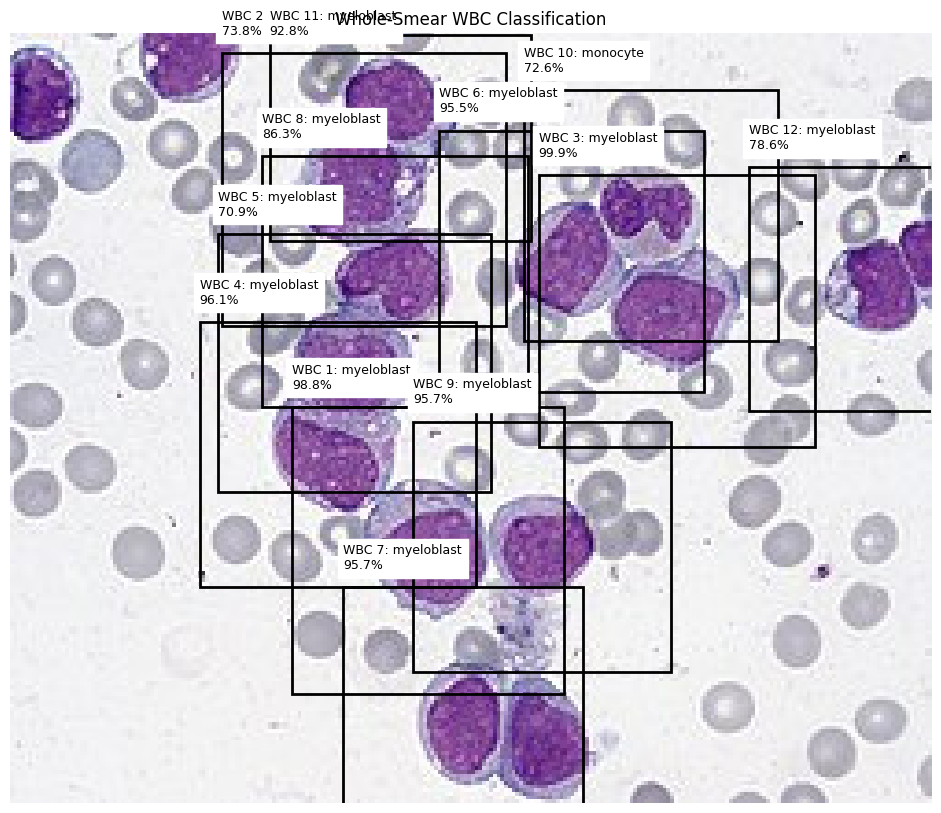

In [364]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
plt.imshow(image)

for i, item in enumerate(clean_wbc_crops):

    x1 = item["x1"]
    y1 = item["y1"]
    x2 = item["x2"]
    y2 = item["y2"]

    prediction = results_df.loc[i, "Prediction"]
    confidence = results_df.loc[i, "Confidence"]

    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
    )

    plt.text(
        x1,
        max(0, y1 - 5),
        f"WBC {i+1}: {prediction}\n{confidence:.1f}%",
        fontsize=9,
        backgroundcolor="white"
    )

plt.axis("off")
plt.title("Whole-Smear WBC Classification")
plt.show()

In [365]:
# Count predicted cell types
cell_counts = results_df["Prediction"].value_counts()

# Calculate percentages
cell_percentages = (
    results_df["Prediction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

summary_df = pd.DataFrame({
    "Cell Type": cell_counts.index,
    "Count": cell_counts.values,
    "Percentage": cell_percentages.loc[cell_counts.index].values
})

print(summary_df.to_string(index=False))

 Cell Type  Count  Percentage
myeloblast     11       91.67
  monocyte      1        8.33


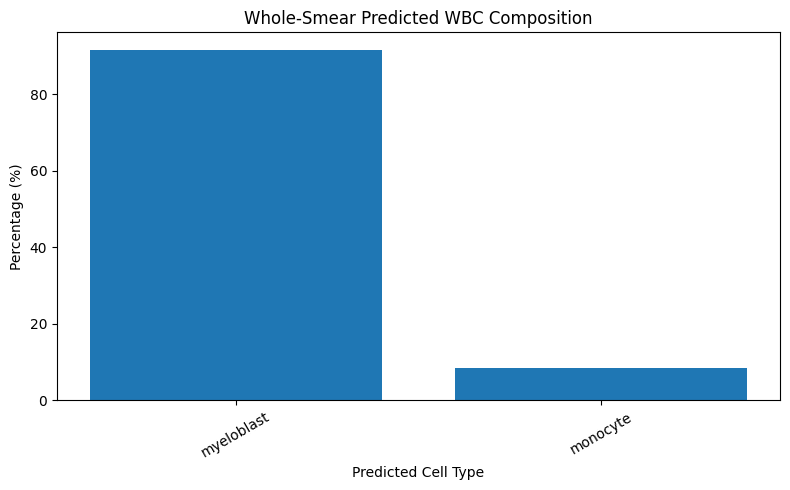

In [366]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["Cell Type"],
    summary_df["Percentage"]
)

plt.ylabel("Percentage (%)")
plt.xlabel("Predicted Cell Type")
plt.title("Whole-Smear Predicted WBC Composition")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()